No local CSV with pit-stop target column found. Attempting Kaggle download...
Path to dataset files: /kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction
Loaded dataset from: /kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/f1_strategy_dataset_v4.csv
Dataset name: f1_strategy_dataset_v4
Raw dataset shape: (101371, 16)
Columns: ['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'Race', 'Year', 'LapTime_Delta', 'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress', 'Normalized_TyreLife', 'Position_Change']
Features after encoding: 73
Final dataset shape: (101371, 74)
Pit-stop rate  : 0.252
=== Training all candidate models ===
  Logistic Regression     Acc=0.8255  F1=0.5970  AUC=0.8640
  Decision Tree           Acc=0.8431  F1=0.6888  AUC=0.8914
  k-NN                    Acc=0.9338  F1=0.8623  AUC=0.9723
  Random Forest           Acc=0.9726  F1=0.9445  AUC=0.9960
  XGBoost                 Acc=

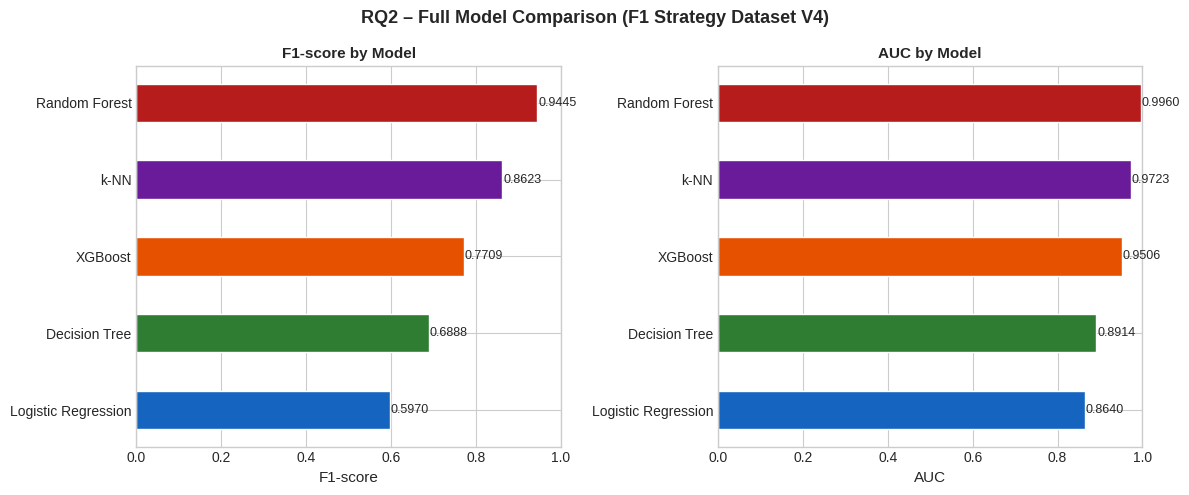

Figure saved → figures/RQ2_model_comparison_bars.png


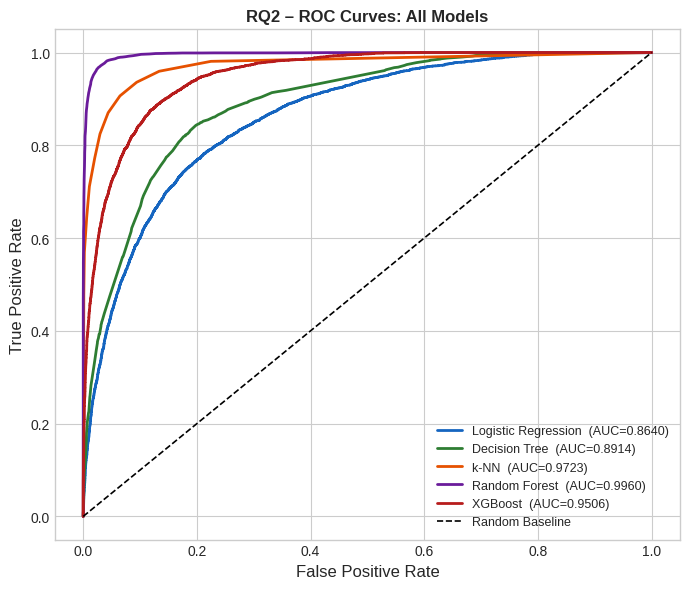

Figure saved → figures/RQ2_roc_curves.png


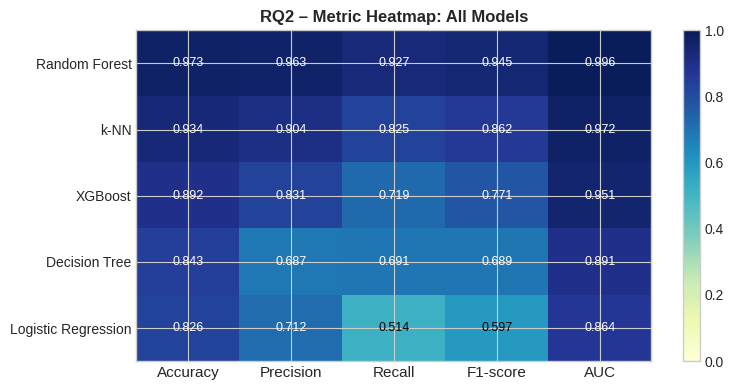

Figure saved → figures/RQ2_metric_heatmap.png


In [1]:
"""
RQ2: Which supervised learning model achieves the best predictive performance
     for pit-stop classification, and how do models compare across all metrics?
"""

try:
    import kagglehub
except ImportError:
    kagglehub = None
import os
import glob
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

os.makedirs("figures", exist_ok=True)
np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#1565C0", "#2E7D32", "#E65100", "#6A1B9A", "#B71C1C", "#006064"]

# ── 1. LOAD DATASET ──────────────────────────────────────────────────────────
# Prefer a local CSV file; fall back to Kaggle download only when needed.
local_csvs = sorted(glob.glob("*.csv"))
raw_path = None

csv_file = None
valid_targets = {"pit_stop", "PitStop", "pitstop", "pit stop"}
for candidate in local_csvs:
    try:
        sample = pd.read_csv(candidate, nrows=5)
    except Exception:
        continue
    if valid_targets.intersection(set(sample.columns.str.replace(" ", "").str.lower())):
        csv_file = candidate
        break

if csv_file is not None:
    print(f"Using local dataset file: {csv_file}")
else:
    if kagglehub is None:
        raise RuntimeError(
            "No local dataset CSV found and kagglehub is not installed. "
            "Please place the dataset CSV in this folder or install kagglehub to enable fallback download."
        )
    print("No local CSV with pit-stop target column found. Attempting Kaggle download...")
    try:
        raw_path = kagglehub.dataset_download("aadigupta1601/f1-strategy-dataset-pit-stop-prediction")
        print("Path to dataset files:", raw_path)
    except Exception as exc:
        raise RuntimeError(
            "Dataset download failed. Please place the dataset CSV in this folder or fix Kaggle SSL/authentication. "
            "If you have the CSV locally, name it something like 'f1_strategy.csv' and rerun."
        ) from exc

    if os.path.isfile(raw_path) and raw_path.lower().endswith(".zip"):
        extract_dir = os.path.splitext(raw_path)[0]
        if not os.path.exists(extract_dir):
            with zipfile.ZipFile(raw_path, "r") as archive:
                archive.extractall(extract_dir)
        data_dir = extract_dir
    else:
        data_dir = raw_path

    csv_files = glob.glob(os.path.join(data_dir, "*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No CSV files found in dataset path: {data_dir}")

    csv_file = sorted(csv_files)[0]

if csv_file is None:
    raise FileNotFoundError("No dataset CSV file could be loaded.")

df = pd.read_csv(csv_file)
dataset_name = os.path.splitext(os.path.basename(csv_file))[0]
print(f"Loaded dataset from: {csv_file}")
print(f"Dataset name: {dataset_name}")
print(f"Raw dataset shape: {df.shape}")
print("Columns:", df.columns.tolist())

# Standardize target column for pit-stop prediction.
found_target = None
for name in df.columns:
    nkey = name.replace(" ", "").replace("_", "").lower()
    if nkey == "pitstop":
        found_target = name
        break

if found_target is None:
    raise ValueError("Target column for pit-stop prediction not found in dataset")

if found_target != "pit_stop":
    df = df.rename(columns={found_target: "pit_stop"})
    found_target = "pit_stop"

# Encode non-numeric target if needed
if df["pit_stop"].dtype == object:
    df["pit_stop"], labels = pd.factorize(df["pit_stop"])
    print("Target encoding:", dict(enumerate(labels)))

# Drop rows with missing labels and keep only useful features
features = [c for c in df.columns if c != "pit_stop"]
X_df = df[features].copy()
X_df = pd.get_dummies(X_df, drop_first=True)

print(f"Features after encoding: {X_df.shape[1]}")

df = pd.concat([X_df, df[["pit_stop"]]], axis=1)
print(f"Final dataset shape: {df.shape}")
print(f"Pit-stop rate  : {df['pit_stop'].mean():.3f}")

# ── 2. PREPROCESSING ────────────────────────────────────────────────────────
FEATURES = [c for c in df.columns if c != "pit_stop"]
X = df[FEATURES].values
y = df["pit_stop"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── 3. TRAIN ALL CANDIDATE MODELS ────────────────────────────────────────────
models_cfg = {
    "Logistic Regression": (LogisticRegression(max_iter=300, random_state=42),            True),
    "Decision Tree":       (DecisionTreeClassifier(max_depth=8, random_state=42),          False),
    "k-NN":                (KNeighborsClassifier(n_neighbors=11),                          True),
    "Random Forest":       (RandomForestClassifier(n_estimators=100, random_state=42,
                                                   n_jobs=-1),                             False),
    "XGBoost":             (XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                          eval_metric="logloss", random_state=42,
                                          n_jobs=-1),                                      False),
}

results = {}
print("=== Training all candidate models ===")
for name, (mdl, scale) in models_cfg.items():
    Xtr = X_train_sc if scale else X_train
    Xte = X_test_sc  if scale else X_test
    mdl.fit(Xtr, y_train)
    yp    = mdl.predict(Xte)
    yprob = mdl.predict_proba(Xte)[:, 1]
    results[name] = {
        "Accuracy":  accuracy_score(y_test, yp),
        "Precision": precision_score(y_test, yp, zero_division=0),
        "Recall":    recall_score(y_test, yp),
        "F1-score":  f1_score(y_test, yp),
        "AUC":       roc_auc_score(y_test, yprob),
        "y_pred": yp, "y_prob": yprob,
    }
    print(f"  {name:22s}  "
          f"Acc={results[name]['Accuracy']:.4f}  "
          f"F1={results[name]['F1-score']:.4f}  "
          f"AUC={results[name]['AUC']:.4f}")

# ── 4. SUMMARY TABLE ─────────────────────────────────────────────────────────
metric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "AUC"]
res_df = pd.DataFrame(
    {name: {m: round(v, 4) for m, v in r.items() if m in metric_cols}
     for name, r in results.items()}
).T.sort_values("F1-score", ascending=False)

print("\n--- Full Model Comparison Table (sorted by F1-score) ---")
print(res_df.to_string())
best_model = res_df["AUC"].idxmax()
print(f"\n★  Best Model (highest AUC): {best_model}")
print(f"   AUC = {res_df.loc[best_model, 'AUC']:.4f}  |  "
      f"F1 = {res_df.loc[best_model, 'F1-score']:.4f}  |  "
      f"Precision = {res_df.loc[best_model, 'Precision']:.4f}")

# ── 5. FIGURE A: horizontal bar – F1 & AUC ───────────────────────────────────
order = sorted(results.keys(), key=lambda m: results[m]["F1-score"])
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, metric in zip(axes, ["F1-score", "AUC"]):
    vals  = [results[m][metric] for m in order]
    bars  = ax.barh(order, vals,
                    color=[COLORS[i % 6] for i in range(len(order))],
                    edgecolor="white", height=0.5)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{v:.4f}", va="center", fontsize=9)
    ax.set_xlabel(metric, fontsize=11)
    ax.set_xlim(0, 1.0)
    ax.set_title(f"{metric} by Model", fontsize=11, fontweight="bold")
fig.suptitle(f"RQ2 – Full Model Comparison ({dataset_name.replace('_', ' ').title()})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/RQ2_model_comparison_bars.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → figures/RQ2_model_comparison_bars.png")

# ── 6. FIGURE B: ROC curves ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
for i, (name, r) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, r["y_prob"])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=COLORS[i % 6], lw=2,
            label=f"{name}  (AUC={roc_auc:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random Baseline")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("RQ2 – ROC Curves: All Models", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("figures/RQ2_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/RQ2_roc_curves.png")

# ── 7. FIGURE C: heatmap of all metrics ──────────────────────────────────────
heat_df = res_df[metric_cols].astype(float)
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(heat_df.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(metric_cols)))
ax.set_xticklabels(metric_cols, fontsize=11)
ax.set_yticks(range(len(heat_df)))
ax.set_yticklabels(heat_df.index, fontsize=10)
for i in range(len(heat_df)):
    for j in range(len(metric_cols)):
        ax.text(j, i, f"{heat_df.iloc[i, j]:.3f}",
                ha="center", va="center", fontsize=9,
                color="white" if heat_df.iloc[i, j] > 0.65 else "black")
ax.set_title("RQ2 – Metric Heatmap: All Models", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/RQ2_metric_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/RQ2_metric_heatmap.png")